# Plot Hovmöller Diagrams for SIC, SST, SSS

In [1]:
## import required packages
import numpy as np
import pandas as pd
import sys
import xarray as xr
import matplotlib.pyplot as plt
import s3fs
import cmocean
import gsw
import matplotlib.dates as mdates
import cartopy.crs as ccrs
import time
import warnings
warnings.filterwarnings("ignore", module='distributed')
warnings.filterwarnings("ignore", module='UserWarning')

In [2]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:40747")
client

<Client: 'tcp://127.0.0.1:40747' processes=8 threads=32, memory=123.95 GiB>

In [3]:
# initialize s3 filesystem
s3_options = dict(anon=False)

In [4]:
# open geometry file for HH field
HH_grid = xr.open_dataset("~/efs-mount-point/mzahn/sassie/HH/GRID/GRID_GEOMETRY_SASSIE_HH_V1R1_NATIVE_LLC1080.nc")

In [5]:
# function to open zarr store with a provided s3 bucket path
def open_zarr_store(s3_path, s3_options):
    # initalize s3 file system
    s3 = s3fs.S3FileSystem(**s3_options)

    # define location of zarr store and open
    store = s3fs.S3Map(root=s3_path, s3=s3, check=False)
    zarr_store = xr.open_zarr(store)
    
    return zarr_store

### Open daily mean ZARR datasets

In [6]:
# open SALT zarr store - [psu]
salt_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SALT_AVG_DAILY.ZARR/', s3_options).SALT

# open THETA zarr store - [degC]
theta_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/THETA_AVG_DAILY.ZARR/', s3_options).THETA

# open SIarea zarr store - [fraction of sea ice, 0 to 1]
ice_da = open_zarr_store('s3://ecco-processed-data/SASSIE/N1/HH/ZARR/SIarea_AVG_DAILY.ZARR/', s3_options).SIarea*100

In [7]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

In [8]:
HH_land_beaufort = HH_grid_land.isel(i=slice(450,750),j=slice(70,390))

### Isolate box along Beaufort

In [9]:
bathy_beaufort = HH_grid.isel(i=slice(450,750),j=slice(70,390)).Depth.where(HH_grid.isel(i=slice(450,750),j=slice(70,390)).Depth>0)

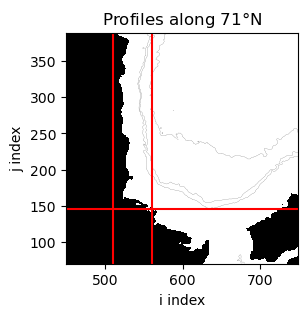

In [16]:
fig, (ax1) = plt.subplots(1,1,figsize=[3,3])
HH_land_beaufort.plot(ax=ax1,vmin=0,vmax=1,cmap='Greys_r',add_colorbar=False);
bathy_beaufort.plot.contour(ax=ax1, colors='k', linewidths=0.1, levels=[500,1000,3000])
ax1.axvline(x=560,c='red')
ax1.axvline(x=510,c='red')
ax1.axhline(y=145,c='red')

ax1.set_xlabel('i index')
ax1.set_ylabel('j index')
ax1.set_title(f'Profiles along 71$\degree$N');

In [21]:
def rotate_dataarray_90ccw(da):
    """
    Rotate a 2D xarray.DataArray (i, j) 90 degrees counterclockwise.
    
    Parameters:
        da (xr.DataArray): Input data array with dims ('i', 'j').
        
    Returns:
        xr.DataArray: Rotated DataArray with dims ('i', 'j').
    """
    rotated = np.rot90(da,3,axes=[0,1])
    
    out = xr.DataArray(
        data=rotated,
        dims=('i','j'),
        coords={
            'i': da['i'],
            'j': da['j']
        },
        name=f"{da.name}"
    )
    
    return out

In [22]:
HH_land_beaufort_rot = rotate_dataarray_90ccw(HH_land_beaufort)
bathy_beaufort_rot = rotate_dataarray_90ccw(bathy_beaufort)

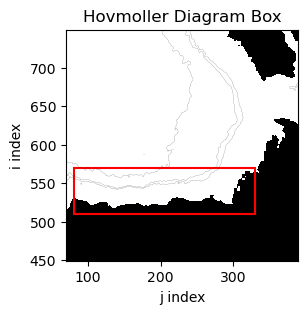

In [29]:
import matplotlib.patches as patches

# Box
x_start = 80
y_start = 510
width = 250
height = 60

fig, (ax1) = plt.subplots(1,1,figsize=[3,3])
HH_land_beaufort_rot.plot(ax=ax1, vmin=0, vmax=1, cmap='Greys_r', add_colorbar=False)
bathy_beaufort_rot.plot.contour(ax=ax1, colors='k', linewidths=0.1, levels=[500,1000,3000])

# Add red box
rect = patches.Rectangle((x_start, y_start), width, height,
                         linewidth=1.5, edgecolor='red', facecolor='none')
ax1.add_patch(rect)

ax1.set_xlabel('j index')
ax1.set_ylabel('i index')
ax1.set_title(f'Hovmoller Diagram Box')

plt.show()

## Plot Hovmöller Diagrams

### SIC

In [71]:
HH_grid_land = HH_grid.maskC.isel(k=0).where(HH_grid.maskC.isel(k=0)==0)

In [90]:
sic_select = ice_da.isel(i=slice(510,568),j=slice(120,381)).where(HH_grid.mask_basin.isel(k=0,i=slice(510,568),j=slice(120,381)))
# sic_select = ice_da.isel(i=slice(510,568),j=slice(120,381)).where(HH_grid.mask_basin.isel(k=0,i=slice(510,540),j=slice(120,381)))

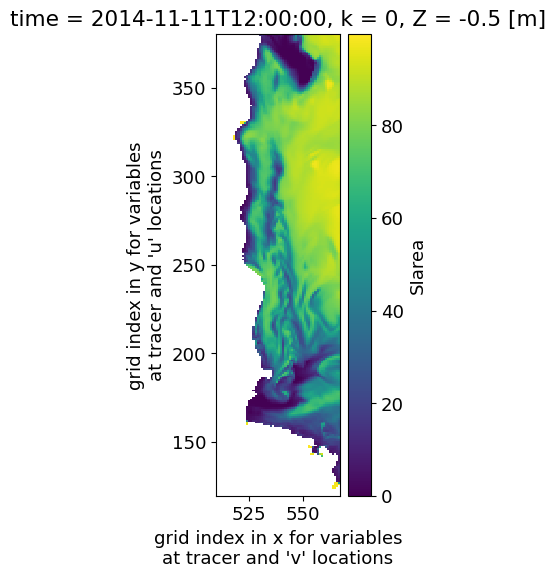

In [91]:
sic_select.isel(time=300).plot(figsize=[2,6]);

In [92]:
# take average over i coord
sic_select_mean = sic_select.mean(dim='i')

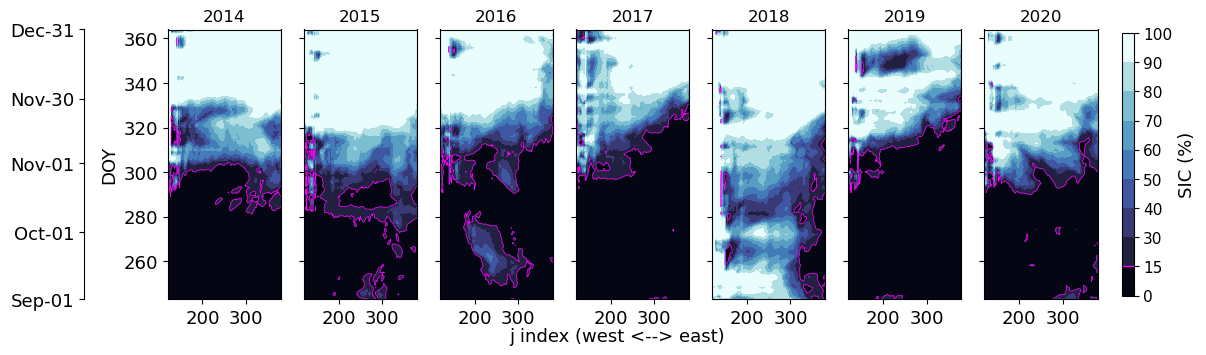

In [93]:
plt.rcParams['font.size'] = 13

# Define years and contour levels
years = range(2014, 2021)
levels = [0, 15, 30, 40, 50, 60, 70, 80, 90, 100]

# Add DOY coordinate to the dataset
sic_select_mean = sic_select_mean.assign_coords(dayofyear=sic_select.time.dt.dayofyear)

# Create figure and subplots
fig, axes = plt.subplots(nrows=1, ncols=7, figsize=(12, 3.5), sharey=True)

for i, year in enumerate(years):
    ax = axes[i]
    
    # Select data for the given year
    ice_conc_year = sic_select_mean.sel(time=str(year))
    
    # Plot Hovmöller Diagram
    cbar_plot = ice_conc_year.plot.contourf(
        ax=ax, x='j', y='dayofyear', cmap=cmocean.cm.ice, levels=levels, add_colorbar=False
    )
    
    # Plot contour line for 80% sea ice concentration
    ice_conc_year.plot.contour(
        ax=ax, x='j', y='dayofyear', levels=[15], colors='magenta', linewidths=0.5
    )
    
    # Formatting
    ax.set_title(f'{year}', fontsize=12)
    # ax.set_xlim(390, 153)
    ax.set_ylim(243, 364)
    ax.set_ylabel("")
    ax.set_xlabel("")
    
# Create a secondary y-axis on the left for Month-Day labels
secax = axes[0].secondary_yaxis('left')
doy_ticks = [243, 273, 304, 333, 364]
secax.set_yticks(doy_ticks)
secax.set_yticklabels([mdates.num2date(d).strftime('%b-%d') for d in doy_ticks])
secax.set_ylabel("")
secax.spines['left'].set_position(('outward', 60))

# Add shared y-axis label
axes[0].set_ylabel('DOY')

# Add shared x-axis label
fig.text(0.5, -0.01, 'j index (west <--> east)', ha='center', fontsize=13)

# Add a single colorbar below the entire figure, outside the subplot bounds
cbar_ax = fig.add_axes([0.92, 0.12, 0.01, 0.75])  # left, bottom, width, height
cbar = fig.colorbar(cbar_plot, cax=cbar_ax, orientation='vertical')
cbar.set_label("SIC (%)")
cbar.ax.axhline(y=15, color='magenta', linewidth=1)
cbar.ax.tick_params(labelsize=11)

plt.show()

### SST

In [114]:
sst_select = theta_da.isel(i=550,j=slice(151,390),k=0)

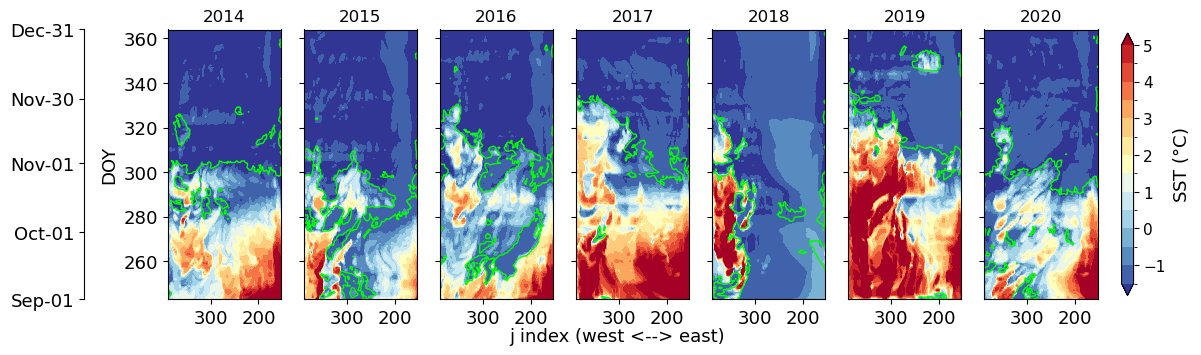

In [125]:
plt.rcParams['font.size'] = 13

# Define years and contour levels
years = range(2014, 2021)
levels=np.arange(-1.5, 5.5, 0.5)

# Add DOY coordinate to the dataset
sst_select = sst_select.assign_coords(dayofyear=sst_select.time.dt.dayofyear)

# Create figure and subplots
fig, axes = plt.subplots(nrows=1, ncols=7, figsize=(12, 3.5), sharey=True)

for i, year in enumerate(years):
    ax = axes[i]
    
    # Select data for the given year
    sst_year = sst_select.sel(time=str(year))
    
    # Plot Hovmöller Diagram
    cbar_plot = sst_year.plot.contourf(
        ax=ax, x='j', y='dayofyear', cmap='RdYlBu_r', levels=levels, add_colorbar=False
    )
    
    # Select data for the given year
    ice_conc_year = sic_select.sel(time=str(year))
    # Plot contour line for 15% sea ice concentration
    ice_conc_year.plot.contour(
        ax=ax, x='j', y='dayofyear', levels=[15], colors='lime', linewidths=1
    )
    
    # Formatting
    ax.set_title(f'{year}', fontsize=12)
    ax.set_xlim(390, 153)
    ax.set_ylim(243, 364)
    ax.set_ylabel("")
    ax.set_xlabel("")
    
# Create a secondary y-axis on the left for Month-Day labels
secax = axes[0].secondary_yaxis('left')
doy_ticks = [243, 273, 304, 333, 364]
secax.set_yticks(doy_ticks)
secax.set_yticklabels([mdates.num2date(d).strftime('%b-%d') for d in doy_ticks])
secax.set_ylabel("")
secax.spines['left'].set_position(('outward', 60))

# Add shared y-axis label
axes[0].set_ylabel('DOY')

# Add shared x-axis label
fig.text(0.5, -0.01, 'j index (west <--> east)', ha='center', fontsize=13)

# Add a single colorbar below the entire figure, outside the subplot bounds
cbar_ax = fig.add_axes([0.92, 0.12, 0.01, 0.75])  # left, bottom, width, height
cbar = fig.colorbar(cbar_plot, cax=cbar_ax, orientation='vertical')
cbar.set_label("SST ($\degree$C)")
cbar.ax.tick_params(labelsize=11)

plt.show()

### SSS

In [126]:
sss_select = salt_da.isel(i=550,j=slice(151,390),k=0)

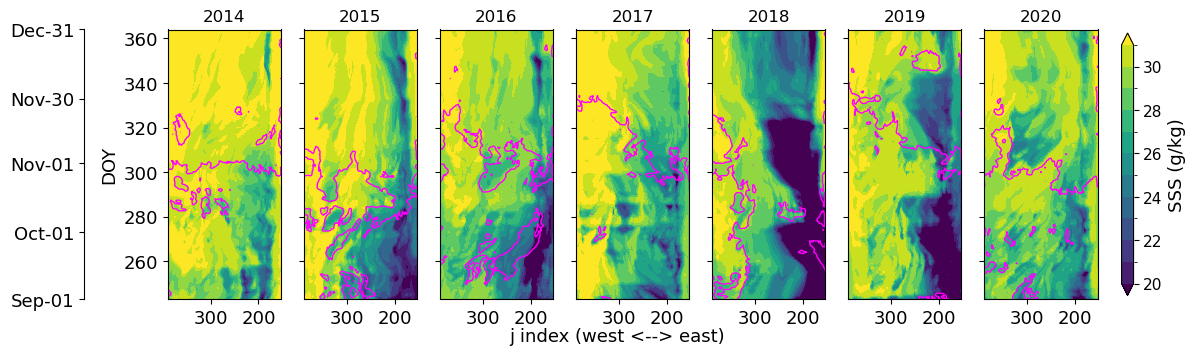

In [127]:
plt.rcParams['font.size'] = 13

# Define years and contour levels
years = range(2014, 2021)
levels = np.arange(20, 32, 1)

# Add DOY coordinate to the dataset
sss_select = sss_select.assign_coords(dayofyear=sss_select.time.dt.dayofyear)

# Create figure and subplots
fig, axes = plt.subplots(nrows=1, ncols=7, figsize=(12, 3.5), sharey=True)

for i, year in enumerate(years):
    ax = axes[i]
    
    # Select data for the given year
    sss_year = sss_select.sel(time=str(year))
    
    # Plot Hovmöller Diagram
    cbar_plot = sss_year.plot.contourf(
        ax=ax, x='j', y='dayofyear', cmap='viridis', levels=levels, add_colorbar=False
    )

    # Select data for the given year
    ice_conc_year = sic_select.sel(time=str(year))
    # Plot contour line for 15% sea ice concentration
    ice_conc_year.plot.contour(
        ax=ax, x='j', y='dayofyear', levels=[15], colors='Magenta', linewidths=1
    )
    
    # Formatting
    ax.set_title(f'{year}', fontsize=12)
    ax.set_xlim(390, 153)
    ax.set_ylim(243, 364)
    ax.set_ylabel("")
    ax.set_xlabel("")
    
# Create a secondary y-axis on the left for Month-Day labels
secax = axes[0].secondary_yaxis('left')
doy_ticks = [243, 273, 304, 333, 364]
secax.set_yticks(doy_ticks)
secax.set_yticklabels([mdates.num2date(d).strftime('%b-%d') for d in doy_ticks])
secax.set_ylabel("")
secax.spines['left'].set_position(('outward', 60))

# Add shared y-axis label
axes[0].set_ylabel('DOY')

# Add shared x-axis label
fig.text(0.5, -0.01, 'j index (west <--> east)', ha='center', fontsize=13)

# Add a single colorbar below the entire figure, outside the subplot bounds
cbar_ax = fig.add_axes([0.92, 0.12, 0.01, 0.75])  # left, bottom, width, height
cbar = fig.colorbar(cbar_plot, cax=cbar_ax, orientation='vertical')
cbar.set_label("SSS (g/kg)")
cbar.ax.tick_params(labelsize=11)

plt.show()

### MLD

In [128]:
sst_select = theta_da.isel(i=550,j=slice(154,390),k=slice(0,17))

In [129]:
sss_select = salt_da.isel(i=550,j=slice(154,390),k=slice(0,17))

In [130]:
def compute_potential_density(SALT_day, THETA_day, ref_lat=70):
    """
    Compute potential density anomaly referenced to 0 dbar.

    Args:
    - SALT_day: DataArray containing salinity (SALT), longitude (XC), and latitude (YC).
    - THETA_day: DataArray containing potential temperature (THETA).
    - ref_lat: Reference latitude for pressure calculation (default is 70°N).

    Returns:
    - sigma0: Potential density anomaly (kg/m³ - 1000).
    """
    # Convert depth (m) to pressure (dbar)
    p = gsw.p_from_z(SALT_day.Z, ref_lat)  # Depth is negative

    # Convert Practical Salinity (SP) to Absolute Salinity (SA)
    SA = gsw.SA_from_SP(SALT_day, p, SALT_day.XC, SALT_day.YC)

    # Convert Potential Temperature to Conservative Temperature
    CT = gsw.conversions.CT_from_pt(SA, THETA_day)

    # Calculate potential density anomaly referenced to 0 dbar
    sigma0 = gsw.sigma0(SA, CT)

    # Add metadata
    sigma0.name = 'potential_density'
    sigma0.attrs['long_name'] = 'potential_density'

    return sigma0 + 1000

In [131]:
def calculate_mld(sigma0_array, density_threshold=0.03):
    """
    Calculate the Mixed Layer Depth (MLD) for a time series of a profile at k=90.
    
    Args:
    - sigma0_array (xr.DataArray): Potential density dataset with dimensions (time, k).
    - density_threshold (float): Density increase threshold to define the MLD (default = 0.03 kg/m^3).
    
    Returns:
    - xr.DataArray: MLD time series corresponding to depth where density exceeds threshold.
    """
    
    # Select surface density
    rho_Z0 = sigma0_array.isel(k=0)
    
    # Compute threshold density
    threshold = (rho_Z0 + density_threshold)
    
    # Compute absolute difference from threshold
    density_minus_threshold = abs(sigma0_array - threshold)
    
    # Find the index of the minimum difference, skipping NaNs
    threshold_idx = density_minus_threshold.argmin(dim='k', skipna=True)
    
    # Extract the corresponding depth value for MLD
    MLD_array = sigma0_array.isel(k=threshold_idx.compute()).Z
    
    return MLD_array, threshold_idx

In [132]:
sigma_line = compute_potential_density(sss_select, sst_select, ref_lat=70)

In [133]:
sigma_line_fall = sigma_line.sel(time=slice('2014', '2020')).where(sigma_line.time.dt.month.isin([8, 9, 10, 11, 12]), drop=True)

In [134]:
# calculate mld and the index of the mld along k coord for EASTERN beaufort
start = time.time()
mld_line, threshold_idx_line = calculate_mld(sigma_line_fall, density_threshold=0.03)
end = time.time()
print(f"Time taken: {np.round(end - start)} seconds")

Time taken: 95.0 seconds


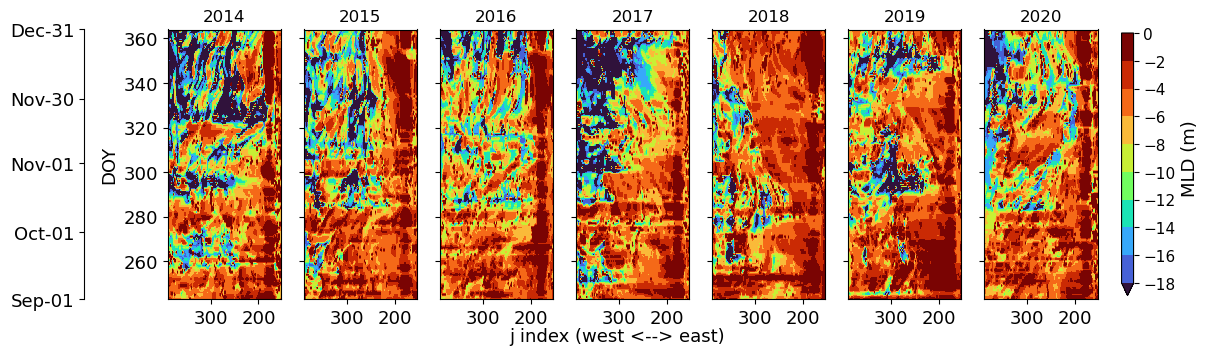

In [143]:
plt.rcParams['font.size'] = 13

# Define years and contour levels
years = range(2014, 2021)
levels = np.arange(-18, 2, 2)

# Add DOY coordinate to the dataset
mld_line = mld_line.assign_coords(dayofyear=mld_line.time.dt.dayofyear)

# Create figure and subplots
fig, axes = plt.subplots(nrows=1, ncols=7, figsize=(12, 3.5), sharey=True)

for i, year in enumerate(years):
    ax = axes[i]
    
    # Select data for the given year
    mld_year = mld_line.sel(time=str(year))
    
    # Plot Hovmöller Diagram
    cbar_plot = mld_year.plot.contourf(
        ax=ax, x='j', y='dayofyear', cmap='turbo', levels=levels, add_colorbar=False, extend='min'
    )
    
    # # Select data for the given year
    # ice_conc_year = sic_select.sel(time=str(year))
    # # Plot contour line for 15% sea ice concentration
    # ice_conc_year.plot.contour(
    #     ax=ax, x='j', y='dayofyear', levels=[15], colors='tab:green', linewidths=1
    # )
    
    # Formatting
    ax.set_title(f'{year}', fontsize=12)
    ax.set_xlim(390, 153)
    ax.set_ylim(243, 364)
    ax.set_ylabel("")
    ax.set_xlabel("")
    
# Create a secondary y-axis on the left for Month-Day labels
secax = axes[0].secondary_yaxis('left')
doy_ticks = [243, 273, 304, 333, 364]
secax.set_yticks(doy_ticks)
secax.set_yticklabels([mdates.num2date(d).strftime('%b-%d') for d in doy_ticks])
secax.set_ylabel("")
secax.spines['left'].set_position(('outward', 60))

# Add shared y-axis label
axes[0].set_ylabel('DOY')

# Add shared x-axis label
fig.text(0.5, -0.01, 'j index (west <--> east)', ha='center', fontsize=13)

# Add a single colorbar below the entire figure, outside the subplot bounds
cbar_ax = fig.add_axes([0.92, 0.12, 0.01, 0.75])  # left, bottom, width, height
cbar = fig.colorbar(cbar_plot, cax=cbar_ax, orientation='vertical')
cbar.set_label("MLD (m)")
cbar.ax.tick_params(labelsize=11)

plt.show()

### OHC in ML

In [139]:
def calculate_cp_from_profile(salinity, temperature, depth, lon=-137, lat=70):
    """
    Calculate specific heat capacity (cp) of seawater from depth, temperature, and salinity.
    
    Parameters:
    - salinity (array): salinity (PSU)
    - temperature (array): temperature (°C)
    - depth (array): depth values (m, negative downward)
    - lon (float): longitude for SA calculation
    - lat (float): latitude for pressure calculation
    
    Args:
    - cp (array): Specific heat capacity (J/kg/deg K) for each depth level
    """
    # Convert depth (m) to pressure (dbar)
    pressure = gsw.p_from_z(depth, lat)  # Negative depth because z is negative downward
    
    # Convert Practical Salinity (SP) to Absolute Salinity (SA)
    SA = gsw.SA_from_SP(salinity, pressure, lon, lat)
    
    # Compute specific heat capacity (cp) in J/(kg K)
    cp = gsw.cp_t_exact(SA, temperature, pressure)
    
    return cp

In [140]:
def calculate_ohc(temp, salinity, density, layer_thickness, threshold_idx):
    """
    Calculate the Ocean Heat Content (OHC) relative to the freezing temperature in surface mixed layer for a time series of profiles.

    Args:
    - temp (xr.DataArray): 2D array of temperature (°C) with dimensions ['time', 'k'].
    - salinity (xr.DataArray): 2D array of salinity (PSU) with dimensions ['time', 'k'].
    - density (xr.DataArray): 2D array of seawater density (kg/m3) with dimensions ['time', 'k'].
    - layer_thickness (xr.DataArray): 1D array representing the thickness of each vertical layer (m).
    - threshold_idx (xr.DataArray): 1D array containing the maximum depth index for the MLD of each profile along the time series.

    Returns:
    - ohc (xr.DataArray): 3D array representing ocean heat content relative to the freezing temperature in the surface mixed layer for each profile (J/m2).
    """
    
    # specific heat capacity of seawater
    cp = calculate_cp_from_profile(salinity, temp, temp.Z, lon=temp.XC, lat=temp.YC)

    # Given array of indices
    indices = threshold_idx.compute()

    # Create mask for surface mixed layer
    mask = temp.k <= indices
    
    # Compute ocean heat content relative to freezing temperature per unit area
    temp_freezing = -1.8

    # Compute the weighted temperature anomaly and then OHC for the surface mixed layer
    weighted_temp_anomaly = (temp - temp_freezing) * layer_thickness
    weighted_temp_anomaly_layer = weighted_temp_anomaly.where(mask) # apply mask for specific depth layer
    ohc = (density * cp * weighted_temp_anomaly_layer).sum(dim='k')  # J/m^2

    # units check: (kg/m3)(J/(kg degC))(degC * m) = J/m2
    
    return ohc

In [115]:
# calculate mld and the index of the mld along k coord for WESTERN beaufort
start = time.time()
mld_pt_west, threshold_idx_west = calculate_mld(sigma_west.sel(time=slice('2019','2020')), density_threshold=0.03)
end = time.time()
print(f"Time taken: {np.round(end - start)} seconds")

Time taken: 34.0 seconds


#### Calculate OHC relative to freezing point

In [148]:
line_depth = HH_grid.isel(i=550,j=slice(154,390),k=slice(0,17)).drF

In [145]:
salt_line = salt_da.isel(i=550,j=slice(154,390),k=slice(0,17))
temp_line = theta_da.isel(i=550,j=slice(154,390),k=slice(0,17))

In [146]:
salt_line_fall = salt_line.sel(time=slice('2014', '2020')).where(salt_line.time.dt.month.isin([8, 9, 10, 11, 12]), drop=True)
temp_line_fall = temp_line.sel(time=slice('2014', '2020')).where(temp_line.time.dt.month.isin([8, 9, 10, 11, 12]), drop=True)

In [228]:
# calculate OHC for line across beaufort
start = time.time()
ohc_mld_line = calculate_ohc(temp_line_fall, salt_line_fall, sigma_line_fall, line_depth, threshold_idx_line)
end = time.time()
print(f"Time taken: {np.round(end - start)} seconds")

Time taken: 108.0 seconds


In [229]:
# there are a few values that are just under zero with temps right around 1.8
ohc_mld_line.sel(time='2014-12-15').values

array([[-2403761.30349829, -1216901.26064519, -1045623.29589736,
        -2017785.79636953,  -412014.79520487,    80405.98989696,
          122453.52279295,   192937.65216338,   687193.8008312 ,
          686546.70569416,   971668.88021689,  1328917.71182   ,
         2611754.95952953,  2068914.93258869,   336924.31540905,
          353786.42020017,   381284.04116149,   424930.81945889,
          480008.20876803,   536065.16557462,   611223.40600663,
          762676.22571023,   937884.29154348,  1134989.61064956,
         1397456.69733628,  1526867.80004934,  1520490.60765275,
         1515362.79283134,  1536271.17746453,  1657796.58028065,
         1861580.04748174,  1800011.31072723,  1782849.95449199,
         1661979.84353852,  1550623.1015306 ,  1310311.3427976 ,
          646604.17059259, 15855279.46352515, 12694762.15535382,
        15905310.63620069, 19855047.25550354, 15158721.43395714,
         5901007.06104987,  6916417.00261515,  8199189.16072936,
         7733392.36732177

In [230]:
# make those all zero
ohc_mld_line = ohc_mld_line.where(ohc_mld_line > 0, 0)

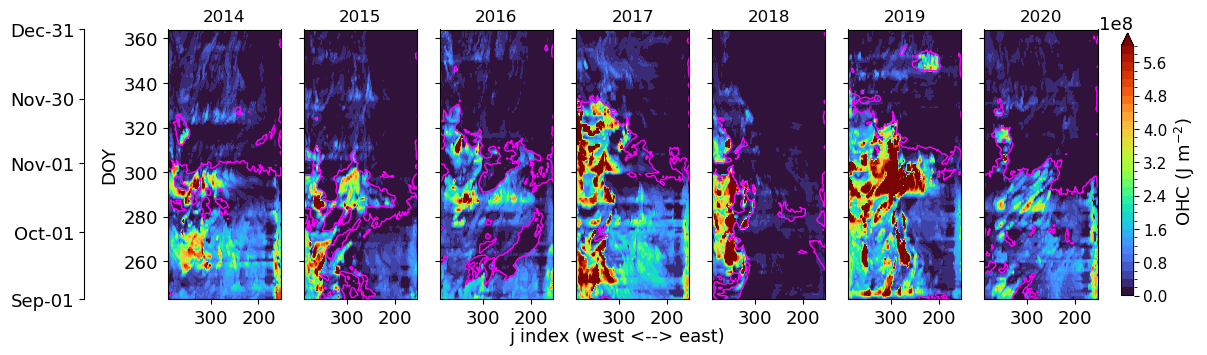

In [231]:
plt.rcParams['font.size'] = 13

# Define years and contour levels
years = range(2014, 2021)
levels = np.arange(0, 6e8 + 1, 2e7)

# Add DOY coordinate to the dataset
ohc_mld_line = ohc_mld_line.assign_coords(dayofyear=ohc_mld_line.time.dt.dayofyear)

# Create figure and subplots
fig, axes = plt.subplots(nrows=1, ncols=7, figsize=(12, 3.5), sharey=True)

for i, year in enumerate(years):
    ax = axes[i]
    
    # Select data for the given year
    ohc_year = ohc_mld_line.sel(time=str(year))
    
    # Plot Hovmöller Diagram
    cbar_plot = ohc_year.plot.contourf(
        ax=ax, x='j', y='dayofyear', cmap='turbo', levels=levels, add_colorbar=False, extend='max'
    )
    
    # Select data for the given year
    ice_conc_year = sic_select.sel(time=str(year))
    # Plot contour line for 15% sea ice concentration
    ice_conc_year.plot.contour(
        ax=ax, x='j', y='dayofyear', levels=[15], colors='magenta', linewidths=1
    )
    
    # Formatting
    ax.set_title(f'{year}', fontsize=12)
    ax.set_xlim(390, 153)
    ax.set_ylim(243, 364)
    ax.set_ylabel("")
    ax.set_xlabel("")
    
# Create a secondary y-axis on the left for Month-Day labels
secax = axes[0].secondary_yaxis('left')
doy_ticks = [243, 273, 304, 333, 364]
secax.set_yticks(doy_ticks)
secax.set_yticklabels([mdates.num2date(d).strftime('%b-%d') for d in doy_ticks])
secax.set_ylabel("")
secax.spines['left'].set_position(('outward', 60))

# Add shared y-axis label
axes[0].set_ylabel('DOY')

# Add shared x-axis label
fig.text(0.5, -0.01, 'j index (west <--> east)', ha='center', fontsize=13)

# Add a single colorbar below the entire figure, outside the subplot bounds
cbar_ax = fig.add_axes([0.92, 0.12, 0.01, 0.75])  # left, bottom, width, height
cbar = fig.colorbar(cbar_plot, cax=cbar_ax, orientation='vertical')
cbar.set_label("OHC (J m$^{-2}$)")
cbar.ax.tick_params(labelsize=11)

plt.show()